# ASL Träning
***Marcus Johansson 2026***

Vi ska försöka använda oss av ett kaggle dataset för träning initialt.
https://www.kaggle.com/datasets/grassknoted/asl-alphabet har höga kaggle poäng, det har ett stor set samt ett test-set med.

Utöver vanliga biblioteken så laddar vi också in mediapipe samt opencv python.
*Vi använder hand_landmarker.task från google, för att få ut landmarks från bilderna.*

Jag har läst lite på poster på nätet, samt manualer. 
Jag kommer dela upp arbetet i flera delar.

Första är att konvertera bilderna av händerna och tecknen, till ren data i csv format.
Detta löser vi med ett separat script och med hjälpa av PipeMedia och OpenCV.

Detta ska vi sen avända för att träna modellen.
Vi kan sen börja utföra tester, vilke modell som passar bäst.


In [46]:

##landmark_extrahering.py
"""Går igenom alla mappar och laddar in 500 bilder från varje mapp, plockar ut landmarks och lägger dessa 21 st till en csv fil"""

'Går igenom alla mappar och laddar in 500 bilder från varje mapp, plockar ut landmarks och lägger dessa 21 st till en csv fil'

In [47]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os
import csv
import pandas as pd
import numpy as np


# -- Configen
DATA_FIL = 'asl_landmarks.csv'


Vad innehåller den csv? Vi vet ju vad vi skapade, men vi vill se vad som finns

In [48]:
data_frame = pd.read_csv(DATA_FIL)

print('Storlek:', data_frame.shape)
print('Bokstäver:', data_frame['label'].unique())
data_frame.head()

#Räkna hur många per klass
print('Antal per klass:')
print('-----------------')
print(data_frame['label'].value_counts().sort_index())

Storlek: (12503, 43)
Bokstäver: <StringArray>
[    'A',     'B',     'C',     'D',     'E',     'F',     'G',     'H',
     'I',     'J',     'K',     'L',     'M',     'N',     'O',     'P',
     'Q',     'R',     'S',     'T',     'U',     'V',     'W',     'X',
     'Y',     'Z',   'del', 'space']
Length: 28, dtype: str
Antal per klass:
-----------------
label
A        456
B        438
C        488
D        494
E        459
F        493
G        475
H        479
I        469
J        445
K        498
L        438
M        286
N        167
O        489
P        495
Q        482
R        482
S        500
T        462
U        458
V        451
W        411
X        449
Y        492
Z        495
del      382
space    370
Name: count, dtype: int64


In [49]:
#skapa data
X = data_frame.drop('label', axis=1).values #vi tar bort label från data och lägger bara värdena i X
Y = data_frame['label'].values #sparar label i y

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (12503, 42)
Y shape: (12503,)


Här gick vi lite vilse först.. vi måste 

In [50]:
#from pandas.api.types import CategoricalDtype
##pd.Categorical..började jag med men det var inte helt rätt. labeleoncode kan decoda tillbaka vilket vi vill
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(Y)

print('Klasser:', le.classes_)
print('Y encoded shape:', y_encoded.shape)
print('Y encoded:', y_encoded)


Klasser: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'space']
Y encoded shape: (12503,)
Y encoded: [ 0  0  0 ... 27 27 27]


In [51]:
from sklearn.model_selection import train_test_split
#dela upp i träning och test, 20% test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Träning: {X_train.shape[0]} exempel')
print(f'Test:    {X_test.shape[0]} exempel')


Träning: 10002 exempel
Test:    2501 exempel


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (10002, 42)
X_test shape: (2501, 42)


In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print('Random Forest tränad!')

Random Forest tränad!


In [54]:
#to demonstrate, we add all these instead of replacing everytime
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, random_state=42)
svm.fit(X_train, y_train)
print('SVM tränad!')


SVM tränad!


In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print('KNN tränad!')


KNN tränad!


In [56]:
from sklearn.metrics import accuracy_score

modeller = {'Random Forest': rf, 'SVM': svm, 'KNN': knn}

for namn, modell in modeller.items():
    y_pred = modell.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{namn}: {acc:.3f}')


Random Forest: 0.992
SVM: 0.992
KNN: 0.968


In [57]:
from sklearn.metrics import classification_report

y_pred = svm.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

           A       0.98      1.00      0.99        91
           B       1.00      1.00      1.00        88
           C       1.00      0.99      0.99        98
           D       1.00      1.00      1.00        99
           E       1.00      0.97      0.98        92
           F       1.00      1.00      1.00        99
           G       0.99      1.00      0.99        95
           H       1.00      1.00      1.00        96
           I       1.00      0.98      0.99        94
           J       1.00      0.99      0.99        89
           K       1.00      1.00      1.00       100
           L       1.00      1.00      1.00        88
           M       0.96      0.95      0.96        57
           N       0.91      0.94      0.93        33
           O       1.00      1.00      1.00        98
           P       1.00      1.00      1.00        99
           Q       0.99      1.00      0.99        96
           R       0.99    

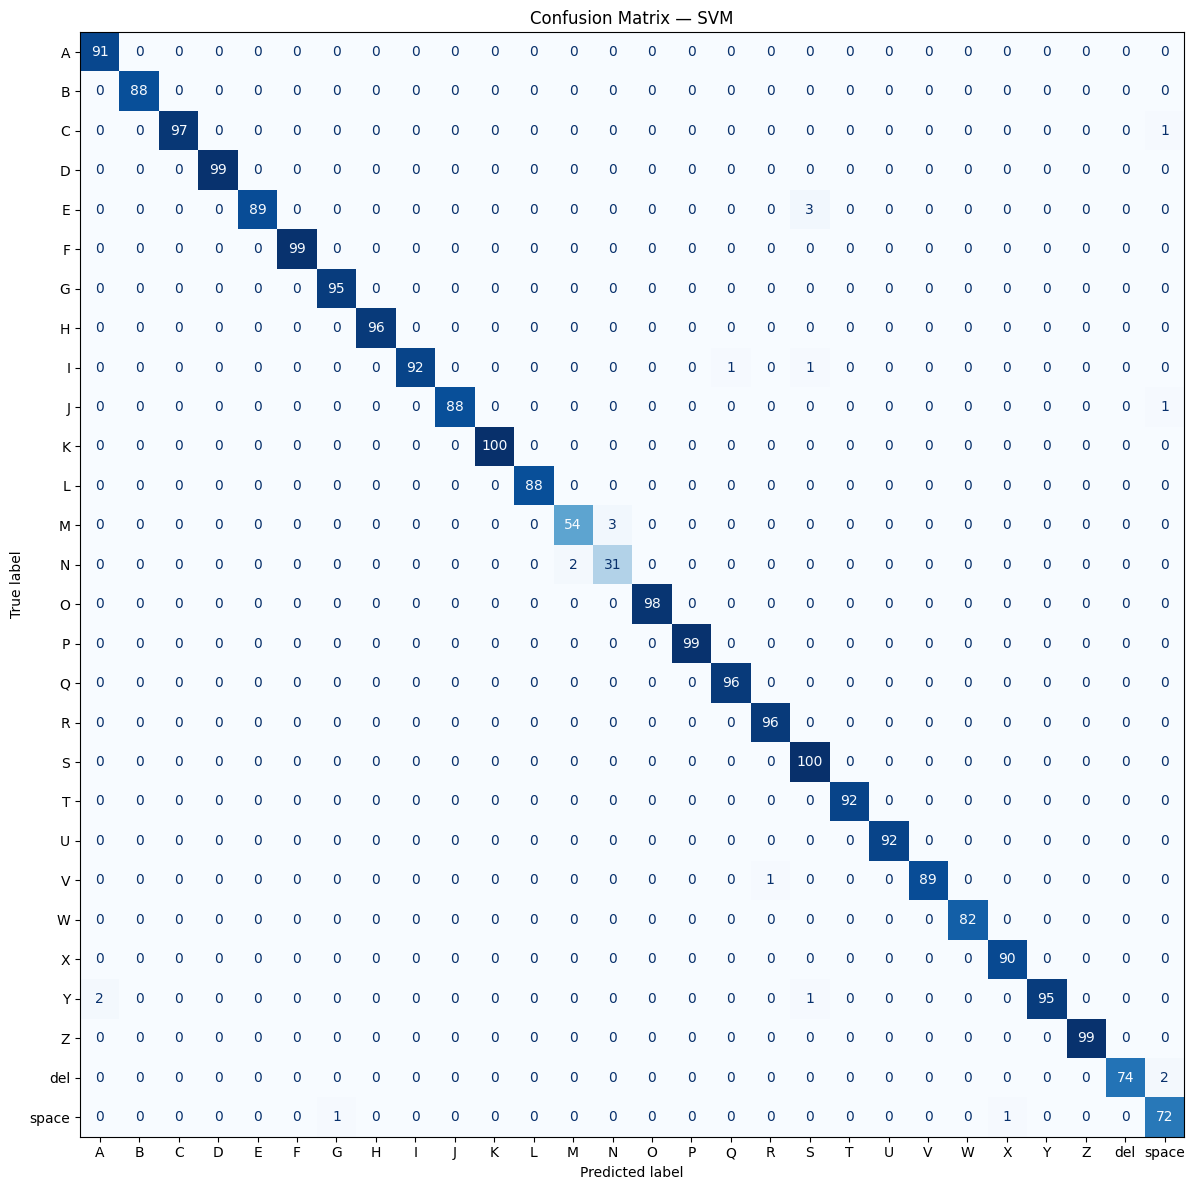

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — SVM')
plt.tight_layout()
plt.show()

#Några sticker ut, M och N mest. Ser man dock på själva handhållningen, så är det ett fingersskillnad på m och n bokstaven. Handen pekar ligger också framför armen vid det tecknet, vilket nog gör det svårare, bra ljus krävs för att få det korrekt. Det uppstår bias av datasetet.

 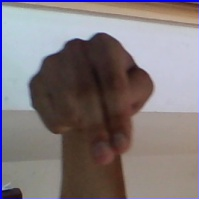 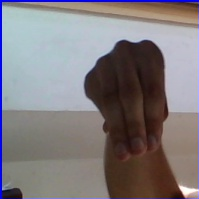

In [59]:
import joblib

joblib.dump(svm, 'asl_modell.pkl')
joblib.dump(scaler, 'asl_scaler.pkl')
joblib.dump(le, 'asl_label_encoder.pkl')

print('Modell sparad!')

Modell sparad!
